In [ ]:
!pip install matplotlib numpy pandas seaborn scipy scikit-learn imbalanced-learn

In [2]:
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns
from scipy.stats import shapiro
from sklearn.preprocessing import MinMaxScaler
import warnings
from sklearn.utils import resample
from imblearn.over_sampling import SMOTE
from sklearn.model_selection import train_test_split

warnings.filterwarnings('ignore')
pd.set_option('display.max_columns', 200)

In [3]:
path = '../dataset/csv/df_'
table_list = ['Orders', 'Customers', 'Products', 'Payments', 'OrderItems']
df_orders = pd.read_csv(f"{path}{table_list[0]}.csv")
df_custs = pd.read_csv(f"{path}{table_list[1]}.csv")
df_prods = pd.read_csv(f"{path}{table_list[2]}.csv")
df_pays = pd.read_csv(f"{path}{table_list[3]}.csv")
df_items = pd.read_csv(f"{path}{table_list[4]}.csv")

df_list = [df_orders, df_custs, df_prods, df_pays, df_items]

In [4]:
for i in range(len(df_list)):
    print(f"Таблица {table_list[i]}")
    display(df_list[i].head(3))
    print('\n')

Таблица Orders


,order_id,customer_id,order_status,order_purchase_timestamp,order_approved_at,order_delivered_timestamp,order_estimated_delivery_date
0,Axfy13Hk4PIk,hCT0x9JiGXBQ,delivered,2017-10-22 18:57:54,2017-10-22 19:14:13,2017-10-26 22:19:52,2017-11-09
1,v6px92oS8cLG,PxA7fv9spyhx,delivered,2018-06-20 21:40:31,2018-06-20 22:20:20,2018-07-03 22:51:22,2018-07-24
2,Ulpf9skrhjfm,g3nXeJkGI0Qw,delivered,2018-02-16 16:19:31,2018-02-17 16:15:35,2018-02-27 01:29:50,2018-03-08




Таблица Customers


,customer_id,customer_zip_code_prefix,customer_city,customer_state
0,hCT0x9JiGXBQ,58125,varzea paulista,SP
1,PxA7fv9spyhx,3112,armacao dos buzios,RJ
2,g3nXeJkGI0Qw,4119,jandira,SP




Таблица Products


,product_id,product_category_name,product_weight_g,product_length_cm,product_height_cm,product_width_cm
0,90K0C1fIyQUf,toys,491.0,19.0,12.0,16.0
1,qejhpMGGVcsl,watches_gifts,440.0,18.0,14.0,17.0
2,qUS5d2pEAyxJ,costruction_tools_garden,2200.0,16.0,16.0,16.0




Таблица Payments


,order_id,payment_sequential,payment_type,payment_installments,payment_value
0,Axfy13Hk4PIk,1,credit_card,1,259.14
1,v6px92oS8cLG,1,credit_card,8,382.39
2,Ulpf9skrhjfm,1,credit_card,4,249.25




Таблица OrderItems


,order_id,product_id,seller_id,price,shipping_charges
0,Axfy13Hk4PIk,90K0C1fIyQUf,ZWM05J9LcBSF,223.51,84.65
1,v6px92oS8cLG,qejhpMGGVcsl,IjlpYfhUbRQs,170.80,23.79
2,Ulpf9skrhjfm,qUS5d2pEAyxJ,77p2EYxcM9MD,64.40,17.38


# 1. Удаляем дубликаты

In [5]:
# Избавимся от дубликатов
for i in range(len(df_list)):
    print(f"Таблица {table_list[i]}")
    print(f"Количество строк до удаления дублей: {len(df_list[i])}")
    df_list[i].drop_duplicates(inplace=True) # Удаляет дубликаты строк, inplace делает это прямо в этом датафрейме
    print(f"Количество строк после удаления дублей: {len(df_list[i])}")
    print('\n')

Таблица Orders
Количество строк до удаления дублей: 89316
Количество строк после удаления дублей: 89316


Таблица Customers
Количество строк до удаления дублей: 89316
Количество строк после удаления дублей: 89316


Таблица Products
Количество строк до удаления дублей: 89316
Количество строк после удаления дублей: 27451


Таблица Payments
Количество строк до удаления дублей: 89316
Количество строк после удаления дублей: 89316


Таблица OrderItems
Количество строк до удаления дублей: 89316
Количество строк после удаления дублей: 89316




In [6]:
# Сделаем слияние датафреймов, т.е. произведём денормализацию
df = df_orders.merge(df_custs, on='customer_id', how='left')
df = df.merge(df_items, on='order_id', how='left')
df = df.merge(df_pays, on='order_id', how='left')
df = df.merge(df_prods, on='product_id', how='left')
df.head()

,order_id,customer_id,order_status,order_purchase_timestamp,order_approved_at,order_delivered_timestamp,order_estimated_delivery_date,customer_zip_code_prefix,customer_city,customer_state,product_id,seller_id,price,shipping_charges,payment_sequential,payment_type,payment_installments,payment_value,product_category_name,product_weight_g,product_length_cm,product_height_cm,product_width_cm
0,Axfy13Hk4PIk,hCT0x9JiGXBQ,delivered,2017-10-22 18:57:54,2017-10-22 19:14:13,2017-10-26 22:19:52,2017-11-09,58125,varzea paulista,SP,90K0C1fIyQUf,ZWM05J9LcBSF,223.51,84.65,1,credit_card,1,259.14,toys,491.0,19.0,12.0,16.0
1,v6px92oS8cLG,PxA7fv9spyhx,delivered,2018-06-20 21:40:31,2018-06-20 22:20:20,2018-07-03 22:51:22,2018-07-24,3112,armacao dos buzios,RJ,qejhpMGGVcsl,IjlpYfhUbRQs,170.80,23.79,1,credit_card,8,382.39,watches_gifts,440.0,18.0,14.0,17.0
2,Ulpf9skrhjfm,g3nXeJkGI0Qw,delivered,2018-02-16 16:19:31,2018-02-17 16:15:35,2018-02-27 01:29:50,2018-03-08,4119,jandira,SP,qUS5d2pEAyxJ,77p2EYxcM9MD,64.40,17.38,1,credit_card,4,249.25,costruction_tools_garden,2200.0,16.0,16.0,16.0
3,bwJVWupf2keN,EOEsCQ6QlpIg,delivered,2018-08-18 18:04:29,2018-08-18 18:15:16,2018-08-27 20:03:51,2018-09-19,18212,uberlandia,MG,639iGvMyv0De,jWzS0ayv9TGf,264.50,30.72,1,credit_card,2,27.79,toys,1450.0,68.0,3.0,48.0
4,Dd0QnrMk9Cj5,mVz5LO2Vd6cL,delivered,2017-12-22 16:44:04,2017-12-22 17:31:31,2018-01-05 19:22:49,2018-01-18,88868,ilhabela,SP,1lycYGcsic2F,l1pYW6GBnPMr,779.90,30.66,1,credit_card,1,76.15,toys,300.0,17.0,4.0,12.0


In [7]:
# Посмотрим сколько байт занимают таблицы
# Для конкретной таблицы:
sum(df_orders.memory_usage(index=False))

5001696

In [8]:
# Проитерируем по всем таблицам и возьмём сумму
bytes_5 = sum([sum(df_of_5.memory_usage(index=False)) for df_of_5 in df_list])

# Посчитаем количество байт после merge
bytes_final = sum(df.memory_usage(index=False))

print(f'Изначальные таблицы: {bytes_5/1024/1024} MB')
print(f'Таблицы после слияния: {bytes_final/1024/1024} MB')
# На больших данных количество используемой памяти может увеличиться очень сильно (например, десятикратно)

Изначальные таблицы: 15.566574096679688 MB
Таблицы после слияния: 15.672821044921875 MB


In [9]:
# Посмотрим уникальные значения статусов
df['order_status'].unique()

<StringArray>
[  'delivered',    'canceled',     'shipped',  'processing',    'invoiced',
 'unavailable',    'approved']
Length: 7, dtype: str

# 2. Оставим только `delivered`

In [10]:
# Отфильтруем только те строки, у которых order_status == 'delivered'
print(f'Количество строк до фильтрации: {len(df)}')
df = df[df.order_status == 'delivered']
print(f'Количество строк после фильтрации: {len(df)}')

Количество строк до фильтрации: 89316
Количество строк после фильтрации: 87428


In [11]:
# Теперь у нас везде order_status == 'delivered', поэтому откинем этот столбец
df = df.drop('order_status', axis=1) # axis=1 говорит о том, что это столбец

In [12]:
df.head()

,order_id,customer_id,order_purchase_timestamp,order_approved_at,order_delivered_timestamp,order_estimated_delivery_date,customer_zip_code_prefix,customer_city,customer_state,product_id,seller_id,price,shipping_charges,payment_sequential,payment_type,payment_installments,payment_value,product_category_name,product_weight_g,product_length_cm,product_height_cm,product_width_cm
0,Axfy13Hk4PIk,hCT0x9JiGXBQ,2017-10-22 18:57:54,2017-10-22 19:14:13,2017-10-26 22:19:52,2017-11-09,58125,varzea paulista,SP,90K0C1fIyQUf,ZWM05J9LcBSF,223.51,84.65,1,credit_card,1,259.14,toys,491.0,19.0,12.0,16.0
1,v6px92oS8cLG,PxA7fv9spyhx,2018-06-20 21:40:31,2018-06-20 22:20:20,2018-07-03 22:51:22,2018-07-24,3112,armacao dos buzios,RJ,qejhpMGGVcsl,IjlpYfhUbRQs,170.80,23.79,1,credit_card,8,382.39,watches_gifts,440.0,18.0,14.0,17.0
2,Ulpf9skrhjfm,g3nXeJkGI0Qw,2018-02-16 16:19:31,2018-02-17 16:15:35,2018-02-27 01:29:50,2018-03-08,4119,jandira,SP,qUS5d2pEAyxJ,77p2EYxcM9MD,64.40,17.38,1,credit_card,4,249.25,costruction_tools_garden,2200.0,16.0,16.0,16.0
3,bwJVWupf2keN,EOEsCQ6QlpIg,2018-08-18 18:04:29,2018-08-18 18:15:16,2018-08-27 20:03:51,2018-09-19,18212,uberlandia,MG,639iGvMyv0De,jWzS0ayv9TGf,264.50,30.72,1,credit_card,2,27.79,toys,1450.0,68.0,3.0,48.0
4,Dd0QnrMk9Cj5,mVz5LO2Vd6cL,2017-12-22 16:44:04,2017-12-22 17:31:31,2018-01-05 19:22:49,2018-01-18,88868,ilhabela,SP,1lycYGcsic2F,l1pYW6GBnPMr,779.90,30.66,1,credit_card,1,76.15,toys,300.0,17.0,4.0,12.0


In [13]:
# Поле order_id всегда уникальный, поэтому тоже не имеет значимости для модели
len(df['order_id'].unique())

87428

In [14]:
# Поле customer_id тоже можно отбросить, потому что в данном датасете они уникальны
len(df['customer_id'].unique())

87428

In [15]:
df = df.drop(['order_id', 'customer_id'], axis=1)
df.head()

,order_purchase_timestamp,order_approved_at,order_delivered_timestamp,order_estimated_delivery_date,customer_zip_code_prefix,customer_city,customer_state,product_id,seller_id,price,shipping_charges,payment_sequential,payment_type,payment_installments,payment_value,product_category_name,product_weight_g,product_length_cm,product_height_cm,product_width_cm
0,2017-10-22 18:57:54,2017-10-22 19:14:13,2017-10-26 22:19:52,2017-11-09,58125,varzea paulista,SP,90K0C1fIyQUf,ZWM05J9LcBSF,223.51,84.65,1,credit_card,1,259.14,toys,491.0,19.0,12.0,16.0
1,2018-06-20 21:40:31,2018-06-20 22:20:20,2018-07-03 22:51:22,2018-07-24,3112,armacao dos buzios,RJ,qejhpMGGVcsl,IjlpYfhUbRQs,170.80,23.79,1,credit_card,8,382.39,watches_gifts,440.0,18.0,14.0,17.0
2,2018-02-16 16:19:31,2018-02-17 16:15:35,2018-02-27 01:29:50,2018-03-08,4119,jandira,SP,qUS5d2pEAyxJ,77p2EYxcM9MD,64.40,17.38,1,credit_card,4,249.25,costruction_tools_garden,2200.0,16.0,16.0,16.0
3,2018-08-18 18:04:29,2018-08-18 18:15:16,2018-08-27 20:03:51,2018-09-19,18212,uberlandia,MG,639iGvMyv0De,jWzS0ayv9TGf,264.50,30.72,1,credit_card,2,27.79,toys,1450.0,68.0,3.0,48.0
4,2017-12-22 16:44:04,2017-12-22 17:31:31,2018-01-05 19:22:49,2018-01-18,88868,ilhabela,SP,1lycYGcsic2F,l1pYW6GBnPMr,779.90,30.66,1,credit_card,1,76.15,toys,300.0,17.0,4.0,12.0


# 3. Обработаем даты

In [16]:
# Первые четыре столбца хранятся в pandas в виде строк
df.info()

<class 'pandas.DataFrame'>
Index: 87428 entries, 0 to 89315
Data columns (total 20 columns):
 #   Column                         Non-Null Count  Dtype  
---  ------                         --------------  -----  
 0   order_purchase_timestamp       87428 non-null  str    
 1   order_approved_at              87419 non-null  str    
 2   order_delivered_timestamp      87422 non-null  str    
 3   order_estimated_delivery_date  87428 non-null  str    
 4   customer_zip_code_prefix       87428 non-null  int64  
 5   customer_city                  87428 non-null  str    
 6   customer_state                 87428 non-null  str    
 7   product_id                     87428 non-null  str    
 8   seller_id                      87428 non-null  str    
 9   price                          87428 non-null  float64
 10  shipping_charges               87428 non-null  float64
 11  payment_sequential             87428 non-null  int64  
 12  payment_type                   87428 non-null  str    
 13  pa

In [17]:
# Преобразуем эти четыре столбца в формат datetime
date_columns = ['order_purchase_timestamp', 'order_approved_at', 'order_delivered_timestamp', 'order_estimated_delivery_date']
df[date_columns] = df[date_columns].apply(pd.to_datetime)
df.info()

<class 'pandas.DataFrame'>
Index: 87428 entries, 0 to 89315
Data columns (total 20 columns):
 #   Column                         Non-Null Count  Dtype         
---  ------                         --------------  -----         
 0   order_purchase_timestamp       87428 non-null  datetime64[us]
 1   order_approved_at              87419 non-null  datetime64[us]
 2   order_delivered_timestamp      87422 non-null  datetime64[us]
 3   order_estimated_delivery_date  87428 non-null  datetime64[us]
 4   customer_zip_code_prefix       87428 non-null  int64         
 5   customer_city                  87428 non-null  str           
 6   customer_state                 87428 non-null  str           
 7   product_id                     87428 non-null  str           
 8   seller_id                      87428 non-null  str           
 9   price                          87428 non-null  float64       
 10  shipping_charges               87428 non-null  float64       
 11  payment_sequential             

In [18]:
df['order_purchase_timestamp'].dt.day

0        22
1        20
2        16
3        18
4        22
         ..
89311    19
89312    15
89313    24
89314    11
89315     9
Name: order_purchase_timestamp, Length: 87428, dtype: int32

# 4. Заменим три связанных столбца на один

In [19]:
# Три последних столбца указывают габариты в cm. Заменим эти поля одним - volume
# Если названия полей на английском, то можно  обращаться к ним через точку
df['prod_vol'] = df.product_height_cm * df.product_width_cm * df.product_length_cm
df = df.drop(['product_height_cm', 'product_width_cm', 'product_length_cm'], axis=1)
df.head()

,order_purchase_timestamp,order_approved_at,order_delivered_timestamp,order_estimated_delivery_date,customer_zip_code_prefix,customer_city,customer_state,product_id,seller_id,price,shipping_charges,payment_sequential,payment_type,payment_installments,payment_value,product_category_name,product_weight_g,prod_vol
0,2017-10-22 18:57:54,2017-10-22 19:14:13,2017-10-26 22:19:52,2017-11-09,58125,varzea paulista,SP,90K0C1fIyQUf,ZWM05J9LcBSF,223.51,84.65,1,credit_card,1,259.14,toys,491.0,3648.0
1,2018-06-20 21:40:31,2018-06-20 22:20:20,2018-07-03 22:51:22,2018-07-24,3112,armacao dos buzios,RJ,qejhpMGGVcsl,IjlpYfhUbRQs,170.80,23.79,1,credit_card,8,382.39,watches_gifts,440.0,4284.0
2,2018-02-16 16:19:31,2018-02-17 16:15:35,2018-02-27 01:29:50,2018-03-08,4119,jandira,SP,qUS5d2pEAyxJ,77p2EYxcM9MD,64.40,17.38,1,credit_card,4,249.25,costruction_tools_garden,2200.0,4096.0
3,2018-08-18 18:04:29,2018-08-18 18:15:16,2018-08-27 20:03:51,2018-09-19,18212,uberlandia,MG,639iGvMyv0De,jWzS0ayv9TGf,264.50,30.72,1,credit_card,2,27.79,toys,1450.0,9792.0
4,2017-12-22 16:44:04,2017-12-22 17:31:31,2018-01-05 19:22:49,2018-01-18,88868,ilhabela,SP,1lycYGcsic2F,l1pYW6GBnPMr,779.90,30.66,1,credit_card,1,76.15,toys,300.0,816.0


# 5 Обработаем NaN

In [20]:
# Перейдём к обработке NULL, NaN
print('Количество NULL в датасете: \n')
print(df.isna().sum()) # выведет сумму таких NaN по каждому столбцу

Количество NULL в датасете: 

order_purchase_timestamp           0
order_approved_at                  9
order_delivered_timestamp          6
order_estimated_delivery_date      0
customer_zip_code_prefix           0
customer_city                      0
customer_state                     0
product_id                         0
seller_id                          0
price                              0
shipping_charges                   0
payment_sequential                 0
payment_type                       0
payment_installments               0
payment_value                      0
product_category_name            289
product_weight_g                  15
prod_vol                          15
dtype: int64


In [21]:
# Строки с пропусками order_approved_at и order_delivered_timestamp придётся удалить, их мы никак не заполним
print(len(df))
df = df.dropna(subset=['order_approved_at', 'order_delivered_timestamp'])
print(df.isna().sum())
print(len(df))


87428
order_purchase_timestamp           0
order_approved_at                  0
order_delivered_timestamp          0
order_estimated_delivery_date      0
customer_zip_code_prefix           0
customer_city                      0
customer_state                     0
product_id                         0
seller_id                          0
price                              0
shipping_charges                   0
payment_sequential                 0
payment_type                       0
payment_installments               0
payment_value                      0
product_category_name            289
product_weight_g                  15
prod_vol                          15
dtype: int64
87413


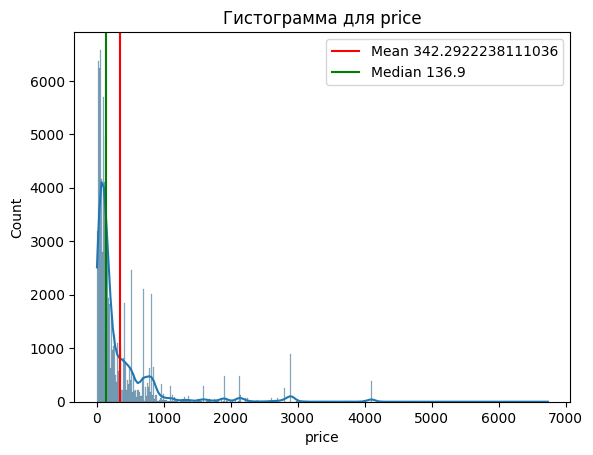

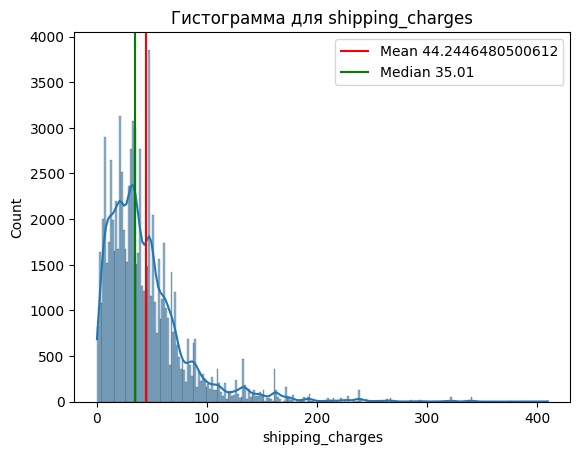

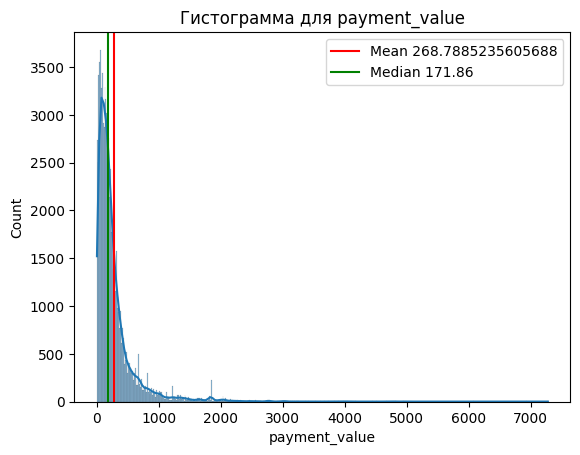

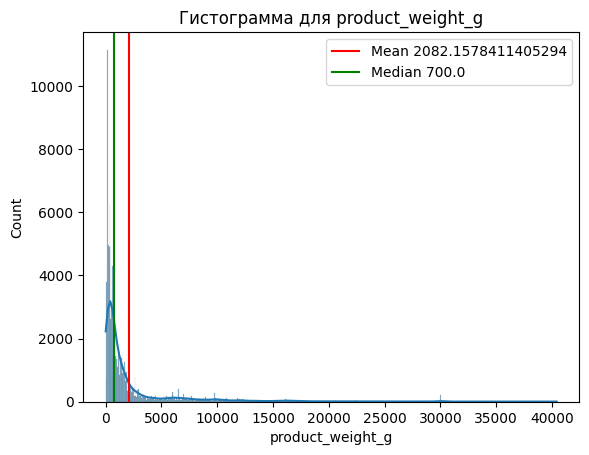

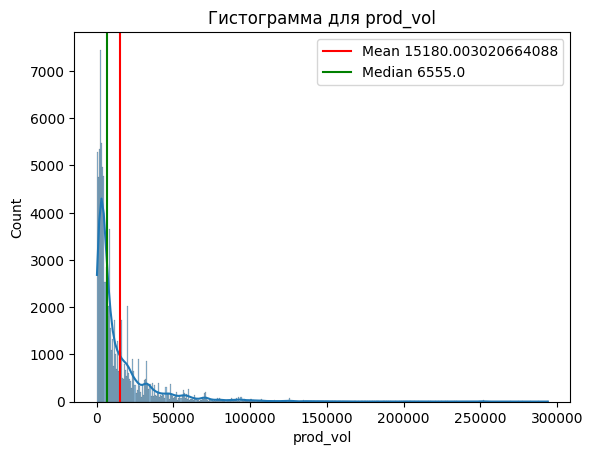

In [22]:
# Возбмём все колонки типа float64
float_columns = df.select_dtypes(include=['float64']).columns
for col in float_columns:
    sns.histplot(df[col], kde=True) # сглаживаемся кривая для гистограммы

    mean_value = df[col].mean()
    median_value = df[col].median()

    plt.axvline(mean_value, color='r', label=f'Mean {mean_value}')
    plt.axvline(median_value, color='g', label=f'Median {median_value}')

    plt.title(f'Гистограмма для {col}')
    plt.legend()

    plt.show()

In [23]:
for col in float_columns:
    print(f'\nСтолбец: {col}')
    print('Статистика до:')
    print(df[col].describe(), '\n')

    Q1 = df[col].quantile(0.25)
    Q3 = df[col].quantile(0.75)
    IQR = Q3 - Q1

    lower_bound = Q1 - 1.5*IQR
    upper_bound = Q3 + 1.5*IQR

    df = df[(df[col] >= lower_bound) & (df[col] <= upper_bound)]
    print('Статистика после:')
    print(df[col].describe(), '\n')




Столбец: price
Статистика до:
count    87413.000000
mean       342.292224
std        559.776730
min          0.850000
25%         59.650000
50%        136.900000
75%        399.200000
max       6735.000000
Name: price, dtype: float64 

Статистика после:
count    81701.000000
mean       220.644794
std        226.414579
min          0.850000
25%         56.890000
50%        127.770000
75%        319.290000
max        907.900000
Name: price, dtype: float64 


Столбец: shipping_charges
Статистика до:
count    81701.000000
mean        44.279394
std         37.733456
min          0.000000
25%         19.960000
50%         35.030000
75%         57.150000
max        409.680000
Name: shipping_charges, dtype: float64 

Статистика после:
count    77459.000000
mean        37.906768
std         24.524639
min          0.000000
25%         18.760000
50%         33.900000
75%         52.370000
max        112.630000
Name: shipping_charges, dtype: float64 


Столбец: payment_value
Статистика до:
count 

In [24]:
# product_weight_g и prod_vol - числовые поля, отражают характеристику товара. Их можно заполнить на медиану
df['product_weight_g'] = df['product_weight_g'].fillna(df['product_weight_g'].median())
df['prod_vol'] = df['prod_vol'].fillna(df['prod_vol'].median())
print(df.isna().sum())
print(len(df))


order_purchase_timestamp           0
order_approved_at                  0
order_delivered_timestamp          0
order_estimated_delivery_date      0
customer_zip_code_prefix           0
customer_city                      0
customer_state                     0
product_id                         0
seller_id                          0
price                              0
shipping_charges                   0
payment_sequential                 0
payment_type                       0
payment_installments               0
payment_value                      0
product_category_name            184
product_weight_g                   0
prod_vol                           0
dtype: int64
57049


In [25]:
# Осталось обработать поле product_category_name
df['product_category_name'].unique()

<StringArray>
[                                   'toys',
                           'watches_gifts',
                'costruction_tools_garden',
                                    'auto',
                              'cool_stuff',
                            'garden_tools',
                         'furniture_decor',
                           'fashion_shoes',
                          'sports_leisure',
                                    'baby',
                          'bed_bath_table',
         'construction_tools_construction',
                             'electronics',
                           'health_beauty',
                         'home_appliances',
                                   'audio',
                          'consoles_games',
                              'stationery',
                   'furniture_living_room',
                   'computers_accessories',
                               'perfumery',
 'kitchen_dining_laundry_garden_furniture',
                'f

In [26]:
# Когда мы работаем с категориальными данными, для заполнения NULL можно использовать часто встречающееся значение - моду
df['product_category_name'].mode()

0    toys
Name: product_category_name, dtype: str

In [27]:
df['product_category_name'] = df['product_category_name'].fillna(df['product_category_name'].mode()[0])

In [28]:
print(df.isna().sum())
print(len(df))

order_purchase_timestamp         0
order_approved_at                0
order_delivered_timestamp        0
order_estimated_delivery_date    0
customer_zip_code_prefix         0
customer_city                    0
customer_state                   0
product_id                       0
seller_id                        0
price                            0
shipping_charges                 0
payment_sequential               0
payment_type                     0
payment_installments             0
payment_value                    0
product_category_name            0
product_weight_g                 0
prod_vol                         0
dtype: int64
57049


# 6. Нормализуем значения float64

In [29]:
# Нормализуем числовые столбцы (либо мин_макс, либо стандартизация).
# Стандартизацию используют только если данные распределены нормально
# У нас это не так, покажем это с помощью статистического теста Шапиро
for col in float_columns:
    _, p = shapiro(df[col])
    print(f'{col} распределён нормально: {p > 0.05}')

price распределён нормально: False
shipping_charges распределён нормально: False
payment_value распределён нормально: False
product_weight_g распределён нормально: False
prod_vol распределён нормально: False


In [30]:
# Сохраним все нормалайзеры мин_макс в словарь и применим к исходному датасету 
scaler = {}
for col in float_columns:
    min_max_scaler = MinMaxScaler()
    scaler[col] = min_max_scaler
    df[col] = min_max_scaler.fit_transform(df[[col]])

df.head()

,order_purchase_timestamp,order_approved_at,order_delivered_timestamp,order_estimated_delivery_date,customer_zip_code_prefix,customer_city,customer_state,product_id,seller_id,price,shipping_charges,payment_sequential,payment_type,payment_installments,payment_value,product_category_name,product_weight_g,prod_vol
0,2017-10-22 18:57:54,2017-10-22 19:14:13,2017-10-26 22:19:52,2017-11-09,58125,varzea paulista,SP,90K0C1fIyQUf,ZWM05J9LcBSF,0.247637,0.751576,1,credit_card,1,0.394534,toys,0.121235,0.128186
1,2018-06-20 21:40:31,2018-06-20 22:20:20,2018-07-03 22:51:22,2018-07-24,3112,armacao dos buzios,RJ,qejhpMGGVcsl,IjlpYfhUbRQs,0.189014,0.211223,1,credit_card,8,0.582186,watches_gifts,0.108642,0.152449
2,2018-02-16 16:19:31,2018-02-17 16:15:35,2018-02-27 01:29:50,2018-03-08,4119,jandira,SP,qUS5d2pEAyxJ,77p2EYxcM9MD,0.070679,0.154311,1,credit_card,4,0.379476,costruction_tools_garden,0.543210,0.145277
3,2018-08-18 18:04:29,2018-08-18 18:15:16,2018-08-27 20:03:51,2018-09-19,18212,uberlandia,MG,639iGvMyv0De,jWzS0ayv9TGf,0.293225,0.272751,1,credit_card,2,0.042296,toys,0.358025,0.362582
4,2017-12-22 16:44:04,2017-12-22 17:31:31,2018-01-05 19:22:49,2018-01-18,88868,ilhabela,SP,1lycYGcsic2F,l1pYW6GBnPMr,0.866439,0.272219,1,credit_card,1,0.115926,toys,0.074074,0.020143


# 7. Кодирование признаков

## Признаки / столбцы / поля
**1) Числовые**
- Стоимость товара [0, +inf)
- Объём товара [0, +inf)
- Возраст [0, 100]
- Остаток на счёте (-inf, +inf)

**2) Бинарные**
- Да / Нет
- 1 / 0
- True / False

**3) ДатаВремя**
- Дата доставки
    - Месяц
    - Год
    - День
    - День недели
    - и т.д.

**4) Категориальные**
- Город
- Цвет
- Уровень образования

*Для ML-модели нужно перевести ВСЕ признаки в числовые*

**Сначала сформируем логический признак `Опоздал / Не опоздал` заказ**

In [31]:
df['is_late'] = (df['order_delivered_timestamp'] > df['order_estimated_delivery_date']).astype(int)
df = df.drop(columns=['order_delivered_timestamp', 'order_estimated_delivery_date'])

**Для даты времени можно использовать тригонометрическое кодирование:**

In [32]:
date_columns = df.select_dtypes(include=["datetime64"]).columns

for col in date_columns:
    month = df[col].dt.month
    dayofweek = df[col].dt.dayofweek
    hour = df[col].dt.hour

    pi_2 = 2*np.pi

    month_sin, month_cos = np.sin(month / 12 * pi_2), np.cos(month / 12 * pi_2)
    dayofweek_sin, dayofweek_cos = np.sin(dayofweek / 7 * pi_2), np.cos(dayofweek / 7 * pi_2)
    hour_sin, hour_cos = np.sin(hour / 24 * pi_2), np.cos(hour / 24 * pi_2)

    df[f'{col}_month_sin'], df[f'{col}_month_cos'] = month_sin, month_cos
    df[f'{col}_dayofweek_sin'], df[f'{col}_dayofweek_cos'] = dayofweek_sin, dayofweek_cos
    df[f'{col}_hour_sin'], df[f'{col}_hour_cos'] = hour_sin, hour_cos

    df = df.drop(columns=[col])

df.head()

,customer_zip_code_prefix,customer_city,customer_state,product_id,seller_id,price,shipping_charges,payment_sequential,payment_type,payment_installments,payment_value,product_category_name,product_weight_g,prod_vol,is_late,order_purchase_timestamp_month_sin,order_purchase_timestamp_month_cos,order_purchase_timestamp_dayofweek_sin,order_purchase_timestamp_dayofweek_cos,order_purchase_timestamp_hour_sin,order_purchase_timestamp_hour_cos,order_approved_at_month_sin,order_approved_at_month_cos,order_approved_at_dayofweek_sin,order_approved_at_dayofweek_cos,order_approved_at_hour_sin,order_approved_at_hour_cos
0,58125,varzea paulista,SP,90K0C1fIyQUf,ZWM05J9LcBSF,0.247637,0.751576,1,credit_card,1,0.394534,toys,0.121235,0.128186,0,-8.660254e-01,0.5,-0.781831,0.623490,-1.000000,-1.836970e-16,-8.660254e-01,0.5,-0.781831,0.623490,-0.965926,2.588190e-01
1,3112,armacao dos buzios,RJ,qejhpMGGVcsl,IjlpYfhUbRQs,0.189014,0.211223,1,credit_card,8,0.582186,watches_gifts,0.108642,0.152449,0,1.224647e-16,-1.0,0.974928,-0.222521,-0.707107,7.071068e-01,1.224647e-16,-1.0,0.974928,-0.222521,-0.500000,8.660254e-01
2,4119,jandira,SP,qUS5d2pEAyxJ,77p2EYxcM9MD,0.070679,0.154311,1,credit_card,4,0.379476,costruction_tools_garden,0.543210,0.145277,0,8.660254e-01,0.5,-0.433884,-0.900969,-0.866025,-5.000000e-01,8.660254e-01,0.5,-0.974928,-0.222521,-0.866025,-5.000000e-01
3,18212,uberlandia,MG,639iGvMyv0De,jWzS0ayv9TGf,0.293225,0.272751,1,credit_card,2,0.042296,toys,0.358025,0.362582,0,-8.660254e-01,-0.5,-0.974928,-0.222521,-1.000000,-1.836970e-16,-8.660254e-01,-0.5,-0.974928,-0.222521,-1.000000,-1.836970e-16
4,88868,ilhabela,SP,1lycYGcsic2F,l1pYW6GBnPMr,0.866439,0.272219,1,credit_card,1,0.115926,toys,0.074074,0.020143,0,-2.449294e-16,1.0,-0.433884,-0.900969,-0.866025,-5.000000e-01,-2.449294e-16,1.0,-0.433884,-0.900969,-0.965926,-2.588190e-01


### Способы кодировки категорий
- **Label encoding** (0 - красный, 1 - зелёный и т.д.). Есть минус: появляется возможность сравнения. Но, например, для уровня образования может подойти.
- **One-hot encoding**. Кодирование при помощи векторов вида (1, 0, 0, ..., 0), (0, 1, 0, ..., 0), (0, 0, 1, ..., 0) ... (0, 0, 0, ..., 1). Есть минус: Если у нас много различных значений, то будет не оптимально.
- **Dummy encoding**. Кодирование при помощи векторов вида (0, 0, ..., 0), (1, 0, ..., 0), (0, 1, ..., 0) ... (0, 0, ..., 1), то есть n-1 размерность от One-hot.
- **Binary encoding**. Проставляет Label, но формирует бинарную репрезентацию в виде последовательности 0 и 1. Минусы: сильно теряем в интерпретируемости, как и у Label появляется возможность сравнения.
- **Target encoding**. Берётся среднее значение целевой переменной для каждой категории в нашем категориальном признаке.


**Теперь закодируем категориальные признаки: customer_city, payment_type и т.д.:**

In [33]:
categorical_columns = df.select_dtypes(exclude='float64').columns
categorical_columns = categorical_columns[~categorical_columns.isin(['is_late', 'payment_sequential', 'payment_installments'])]
print('Количество уникальных значений каждой категории:')
for col in categorical_columns:
    print(f'{col}: {len(df[col].unique())}')

Количество уникальных значений каждой категории:
customer_zip_code_prefix: 12293
customer_city: 3196
customer_state: 27
product_id: 18577
seller_id: 2374
payment_type: 4
product_category_name: 70


In [34]:
df = pd.get_dummies(df, columns=['payment_type'], dtype='int64') # One-hot кодирование (в общем-то оно и Dummy)
categorical_columns = categorical_columns[categorical_columns != 'payment_type'] # исключим этот столбец
df

,customer_zip_code_prefix,customer_city,customer_state,product_id,seller_id,price,shipping_charges,payment_sequential,payment_installments,payment_value,product_category_name,product_weight_g,prod_vol,is_late,order_purchase_timestamp_month_sin,order_purchase_timestamp_month_cos,order_purchase_timestamp_dayofweek_sin,order_purchase_timestamp_dayofweek_cos,order_purchase_timestamp_hour_sin,order_purchase_timestamp_hour_cos,order_approved_at_month_sin,order_approved_at_month_cos,order_approved_at_dayofweek_sin,order_approved_at_dayofweek_cos,order_approved_at_hour_sin,order_approved_at_hour_cos,payment_type_credit_card,payment_type_debit_card,payment_type_voucher,payment_type_wallet
0,58125,varzea paulista,SP,90K0C1fIyQUf,ZWM05J9LcBSF,0.247637,0.751576,1,1,0.394534,toys,0.121235,0.128186,0,-8.660254e-01,0.500000,-0.781831,0.623490,-1.000000,-1.836970e-16,-8.660254e-01,0.500000,-0.781831,0.623490,-0.965926,2.588190e-01,1,0,0,0
1,3112,armacao dos buzios,RJ,qejhpMGGVcsl,IjlpYfhUbRQs,0.189014,0.211223,1,8,0.582186,watches_gifts,0.108642,0.152449,0,1.224647e-16,-1.000000,0.974928,-0.222521,-0.707107,7.071068e-01,1.224647e-16,-1.000000,0.974928,-0.222521,-0.500000,8.660254e-01,1,0,0,0
2,4119,jandira,SP,qUS5d2pEAyxJ,77p2EYxcM9MD,0.070679,0.154311,1,4,0.379476,costruction_tools_garden,0.543210,0.145277,0,8.660254e-01,0.500000,-0.433884,-0.900969,-0.866025,-5.000000e-01,8.660254e-01,0.500000,-0.974928,-0.222521,-0.866025,-5.000000e-01,1,0,0,0
3,18212,uberlandia,MG,639iGvMyv0De,jWzS0ayv9TGf,0.293225,0.272751,1,2,0.042296,toys,0.358025,0.362582,0,-8.660254e-01,-0.500000,-0.974928,-0.222521,-1.000000,-1.836970e-16,-8.660254e-01,-0.500000,-0.974928,-0.222521,-1.000000,-1.836970e-16,1,0,0,0
4,88868,ilhabela,SP,1lycYGcsic2F,l1pYW6GBnPMr,0.866439,0.272219,1,1,0.115926,toys,0.074074,0.020143,0,-2.449294e-16,1.000000,-0.433884,-0.900969,-0.866025,-5.000000e-01,-2.449294e-16,1.000000,-0.433884,-0.900969,-0.965926,-2.588190e-01,1,0,0,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
89307,28922,maringa,PR,4xupTEMXxGZU,KH9VVC2iPaCb,0.141157,0.209536,1,6,0.067829,toys,0.024691,0.031817,0,-8.660254e-01,-0.500000,0.000000,1.000000,0.000000,1.000000e+00,-8.660254e-01,-0.500000,0.781831,0.623490,0.500000,8.660254e-01,1,0,0,0
89308,5655,barra bonita,SP,nLwFAMRy0Lsk,5jmVaCDVvTba,0.072458,0.014561,1,5,0.333176,toys,0.074074,0.240806,0,-5.000000e-01,-0.866025,0.974928,-0.222521,-0.965926,2.588190e-01,-5.000000e-01,-0.866025,0.433884,-0.900969,-0.866025,-5.000000e-01,1,0,0,0
89312,99835,itapevi,SP,KXSbyJWtMMwZ,BFS9XJPapWv0,0.312688,0.014561,1,1,0.162683,toys,0.148148,0.145277,0,-2.449294e-16,1.000000,-0.433884,-0.900969,0.258819,-9.659258e-01,-2.449294e-16,1.000000,-0.974928,-0.222521,0.500000,8.660254e-01,0,0,0,1
89313,2540,sao paulo,SP,EG4wDSpFyTth,TuPm19CMKvrM,0.063672,0.036314,1,1,0.573051,health_beauty,0.061728,0.140089,0,-5.000000e-01,-0.866025,0.781831,0.623490,1.000000,6.123234e-17,-5.000000e-01,-0.866025,0.781831,0.623490,0.258819,-9.659258e-01,1,0,0,0


In [35]:
# остальное будем кодировать через Target
target_enc_cols = []
target_encoding = {}

for col in categorical_columns:
    target_enc_col = f'{col}_enc'
    target_mean = df.groupby(col)['is_late'].mean()
    target_encoding[col] = target_mean
    df[target_enc_col] = df[col].map(target_mean)
    df = df.drop(columns=[col])
    target_enc_cols.append(target_enc_col)

In [36]:
df

,price,shipping_charges,payment_sequential,payment_installments,payment_value,product_weight_g,prod_vol,is_late,order_purchase_timestamp_month_sin,order_purchase_timestamp_month_cos,order_purchase_timestamp_dayofweek_sin,order_purchase_timestamp_dayofweek_cos,order_purchase_timestamp_hour_sin,order_purchase_timestamp_hour_cos,order_approved_at_month_sin,order_approved_at_month_cos,order_approved_at_dayofweek_sin,order_approved_at_dayofweek_cos,order_approved_at_hour_sin,order_approved_at_hour_cos,payment_type_credit_card,payment_type_debit_card,payment_type_voucher,payment_type_wallet,customer_zip_code_prefix_enc,customer_city_enc,customer_state_enc,product_id_enc,seller_id_enc,product_category_name_enc
0,0.247637,0.751576,1,1,0.394534,0.121235,0.128186,0,-8.660254e-01,0.500000,-0.781831,0.623490,-1.000000,-1.836970e-16,-8.660254e-01,0.500000,-0.781831,0.623490,-0.965926,2.588190e-01,1,0,0,0,0.000000,0.075472,0.051817,0.000000,0.107527,0.075408
1,0.189014,0.211223,1,8,0.582186,0.108642,0.152449,0,1.224647e-16,-1.000000,0.974928,-0.222521,-0.707107,7.071068e-01,1.224647e-16,-1.000000,0.974928,-0.222521,-0.500000,8.660254e-01,1,0,0,0,0.500000,0.500000,0.122304,0.000000,0.000000,0.085271
2,0.070679,0.154311,1,4,0.379476,0.543210,0.145277,0,8.660254e-01,0.500000,-0.433884,-0.900969,-0.866025,-5.000000e-01,8.660254e-01,0.500000,-0.974928,-0.222521,-0.866025,-5.000000e-01,1,0,0,0,0.000000,0.080000,0.051817,0.000000,0.000000,0.047619
3,0.293225,0.272751,1,2,0.042296,0.358025,0.362582,0,-8.660254e-01,-0.500000,-0.974928,-0.222521,-1.000000,-1.836970e-16,-8.660254e-01,-0.500000,-0.974928,-0.222521,-1.000000,-1.836970e-16,1,0,0,0,0.000000,0.047872,0.055478,0.000000,0.000000,0.075408
4,0.866439,0.272219,1,1,0.115926,0.074074,0.020143,0,-2.449294e-16,1.000000,-0.433884,-0.900969,-0.866025,-5.000000e-01,-2.449294e-16,1.000000,-0.433884,-0.900969,-0.965926,-2.588190e-01,1,0,0,0,0.037037,0.037037,0.051817,0.000000,0.094340,0.075408
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
89307,0.141157,0.209536,1,6,0.067829,0.024691,0.031817,0,-8.660254e-01,-0.500000,0.000000,1.000000,0.000000,1.000000e+00,-8.660254e-01,-0.500000,0.781831,0.623490,0.500000,8.660254e-01,1,0,0,0,0.000000,0.064706,0.042326,0.000000,0.103846,0.075408
89308,0.072458,0.014561,1,5,0.333176,0.074074,0.240806,0,-5.000000e-01,-0.866025,0.974928,-0.222521,-0.965926,2.588190e-01,-5.000000e-01,-0.866025,0.433884,-0.900969,-0.866025,-5.000000e-01,1,0,0,0,0.125000,0.125000,0.051817,0.000000,0.048387,0.075408
89312,0.312688,0.014561,1,1,0.162683,0.148148,0.145277,0,-2.449294e-16,1.000000,-0.433884,-0.900969,0.258819,-9.659258e-01,-2.449294e-16,1.000000,-0.974928,-0.222521,0.500000,8.660254e-01,0,0,0,1,0.000000,0.042105,0.051817,0.000000,0.000000,0.075408
89313,0.063672,0.036314,1,1,0.573051,0.061728,0.140089,0,-5.000000e-01,-0.866025,0.781831,0.623490,1.000000,6.123234e-17,-5.000000e-01,-0.866025,0.781831,0.623490,0.258819,-9.659258e-01,1,0,0,0,0.000000,0.053633,0.051817,0.066667,0.054605,0.085519


In [37]:
# Посмотрим статистику по новым столбцам
for col in target_enc_cols:
    print(f'\nСтолбец {col}')
    print(df[col].describe(), '\n')


Столбец customer_zip_code_prefix_enc
count    57049.000000
mean         0.074936
std          0.148114
min          0.000000
25%          0.000000
50%          0.000000
75%          0.100000
max          1.000000
Name: customer_zip_code_prefix_enc, dtype: float64 


Столбец customer_city_enc
count    57049.000000
mean         0.074936
std          0.080528
min          0.000000
25%          0.037736
50%          0.053633
75%          0.101911
max          1.000000
Name: customer_city_enc, dtype: float64 


Столбец customer_state_enc
count    57049.000000
mean         0.074936
std          0.035778
min          0.010309
25%          0.051817
50%          0.055478
75%          0.103896
max          0.267606
Name: customer_state_enc, dtype: float64 


Столбец product_id_enc
count    57049.000000
mean         0.074936
std          0.168852
min          0.000000
25%          0.000000
50%          0.000000
75%          0.080645
max          1.000000
Name: product_id_enc, dtype: float64 


С

## Корреляционный анализ

$$\rho_{x,y}=\frac{cov(x,y)}{\sigma_x \sigma_y} \in [-1, +1]$$
$$\sigma_x = \sqrt{D_x} = \sqrt{\frac{1}{n}\Sigma_i (x_i - \overline{x})^2}$$
$$cov(x,y) = M((x-\overline{x})\cdot(y-\overline{y}))


In [38]:
corr = df.corr()
corr

,price,shipping_charges,payment_sequential,payment_installments,payment_value,product_weight_g,prod_vol,is_late,order_purchase_timestamp_month_sin,order_purchase_timestamp_month_cos,order_purchase_timestamp_dayofweek_sin,order_purchase_timestamp_dayofweek_cos,order_purchase_timestamp_hour_sin,order_purchase_timestamp_hour_cos,order_approved_at_month_sin,order_approved_at_month_cos,order_approved_at_dayofweek_sin,order_approved_at_dayofweek_cos,order_approved_at_hour_sin,order_approved_at_hour_cos,payment_type_credit_card,payment_type_debit_card,payment_type_voucher,payment_type_wallet,customer_zip_code_prefix_enc,customer_city_enc,customer_state_enc,product_id_enc,seller_id_enc,product_category_name_enc
price,1.000000,-0.011863,-0.011198,-0.029368,-0.013251,-0.032413,-0.031005,-0.013718,0.003793,0.016931,0.001605,-0.003731,0.006376,0.004199,0.004279,0.016699,-0.002366,-0.009644,0.008747,0.008336,-0.009485,-0.002821,0.002365,0.010084,-0.009690,-0.009229,-0.012107,-0.023277,-0.031170,-0.014628
shipping_charges,-0.011863,1.000000,0.019349,0.036434,0.012500,0.023319,0.020684,0.004085,-0.015564,0.027451,-0.006116,-0.010378,0.008115,-0.003445,-0.014829,0.027200,-0.015291,-0.004786,0.008492,-0.000326,-0.002643,-0.014498,0.013189,-0.000100,0.009347,0.013155,0.027484,-0.002043,0.002022,0.003491
payment_sequential,-0.011198,0.019349,1.000000,-0.082105,0.011787,0.040339,0.044863,-0.016064,-0.020836,-0.022418,0.035089,0.014488,-0.024395,0.023796,-0.020948,-0.022483,0.012120,0.013883,-0.054742,-0.013530,-0.202190,-0.009242,0.506637,-0.062234,-0.021657,-0.002859,-0.014600,-0.021081,-0.023926,-0.002535
payment_installments,-0.029368,0.036434,-0.082105,1.000000,-0.002161,0.155863,0.099589,0.005183,-0.029171,-0.010610,-0.031657,-0.001913,-0.014123,0.026222,-0.029007,-0.009529,-0.049889,0.025172,-0.169967,-0.122658,0.404984,-0.084399,-0.161785,-0.331981,0.017152,0.023698,0.065327,0.002010,-0.006940,0.020405
payment_value,-0.013251,0.012500,0.011787,-0.002161,1.000000,0.001568,-0.002619,-0.010304,0.008843,-0.003596,0.005771,0.014116,-0.002767,-0.000436,0.008398,-0.003515,0.008168,0.007918,-0.006298,0.001859,0.003187,-0.005999,-0.003522,0.000336,-0.015262,-0.007142,-0.000554,-0.013121,-0.013634,0.005322
product_weight_g,-0.032413,0.023319,0.040339,0.155863,0.001568,1.000000,0.584869,0.011100,-0.014865,-0.004328,-0.006483,0.006886,-0.007505,-0.003936,-0.015162,-0.004144,-0.003291,0.010970,-0.011673,-0.010070,0.017706,-0.011880,0.008237,-0.020736,0.012456,0.010134,0.014909,0.017308,-0.000516,-0.020348
prod_vol,-0.031005,0.020684,0.044863,0.099589,-0.002619,0.584869,1.000000,-0.002490,-0.043637,-0.006841,-0.003054,0.010276,-0.007496,-0.000370,-0.043668,-0.006324,-0.001222,0.009468,-0.016814,-0.008181,0.005975,-0.005424,0.026769,-0.020300,-0.001149,-0.003578,-0.002576,-0.003882,-0.029056,-0.049487
is_late,-0.013718,0.004085,-0.016064,0.005183,-0.010304,0.011100,-0.002490,1.000000,0.069586,0.075715,0.003202,0.013085,-0.011945,0.009035,0.071031,0.075129,0.000570,0.007282,0.000459,0.009272,-0.007059,0.001486,-0.009876,0.013056,0.562552,0.305852,0.135888,0.641317,0.285268,0.040621
order_purchase_timestamp_month_sin,0.003793,-0.015564,-0.020836,-0.029171,0.008843,-0.014865,-0.043637,0.069586,1.000000,0.071528,0.003095,-0.006267,0.000332,-0.009924,0.997619,0.063685,0.008668,0.001278,-0.009464,-0.014796,0.005465,-0.024299,0.000839,0.000997,0.032456,0.024655,-0.000612,0.057046,0.047932,0.017888
order_purchase_timestamp_month_cos,0.016931,0.027451,-0.022418,-0.010610,-0.003596,-0.004328,-0.006841,0.075715,0.071528,1.000000,-0.020007,-0.016424,-0.006418,0.004734,0.080133,0.997895,-0.028900,-0.004480,0.023022,0.009879,-0.011549,-0.031914,-0.000577,0.023123,0.038006,0.024168,0.011922,0.065857,0.042095,0.017538


In [39]:
mask = np.triu(np.ones_like(corr, dtype=bool))
mask

array([[ True,  True,  True,  True,  True,  True,  True,  True,  True,
         True,  True,  True,  True,  True,  True,  True,  True,  True,
         True,  True,  True,  True,  True,  True,  True,  True,  True,
         True,  True,  True],
       [False,  True,  True,  True,  True,  True,  True,  True,  True,
         True,  True,  True,  True,  True,  True,  True,  True,  True,
         True,  True,  True,  True,  True,  True,  True,  True,  True,
         True,  True,  True],
       [False, False,  True,  True,  True,  True,  True,  True,  True,
         True,  True,  True,  True,  True,  True,  True,  True,  True,
         True,  True,  True,  True,  True,  True,  True,  True,  True,
         True,  True,  True],
       [False, False, False,  True,  True,  True,  True,  True,  True,
         True,  True,  True,  True,  True,  True,  True,  True,  True,
         True,  True,  True,  True,  True,  True,  True,  True,  True,
         True,  True,  True],
       [False, False, False,

<Axes: >

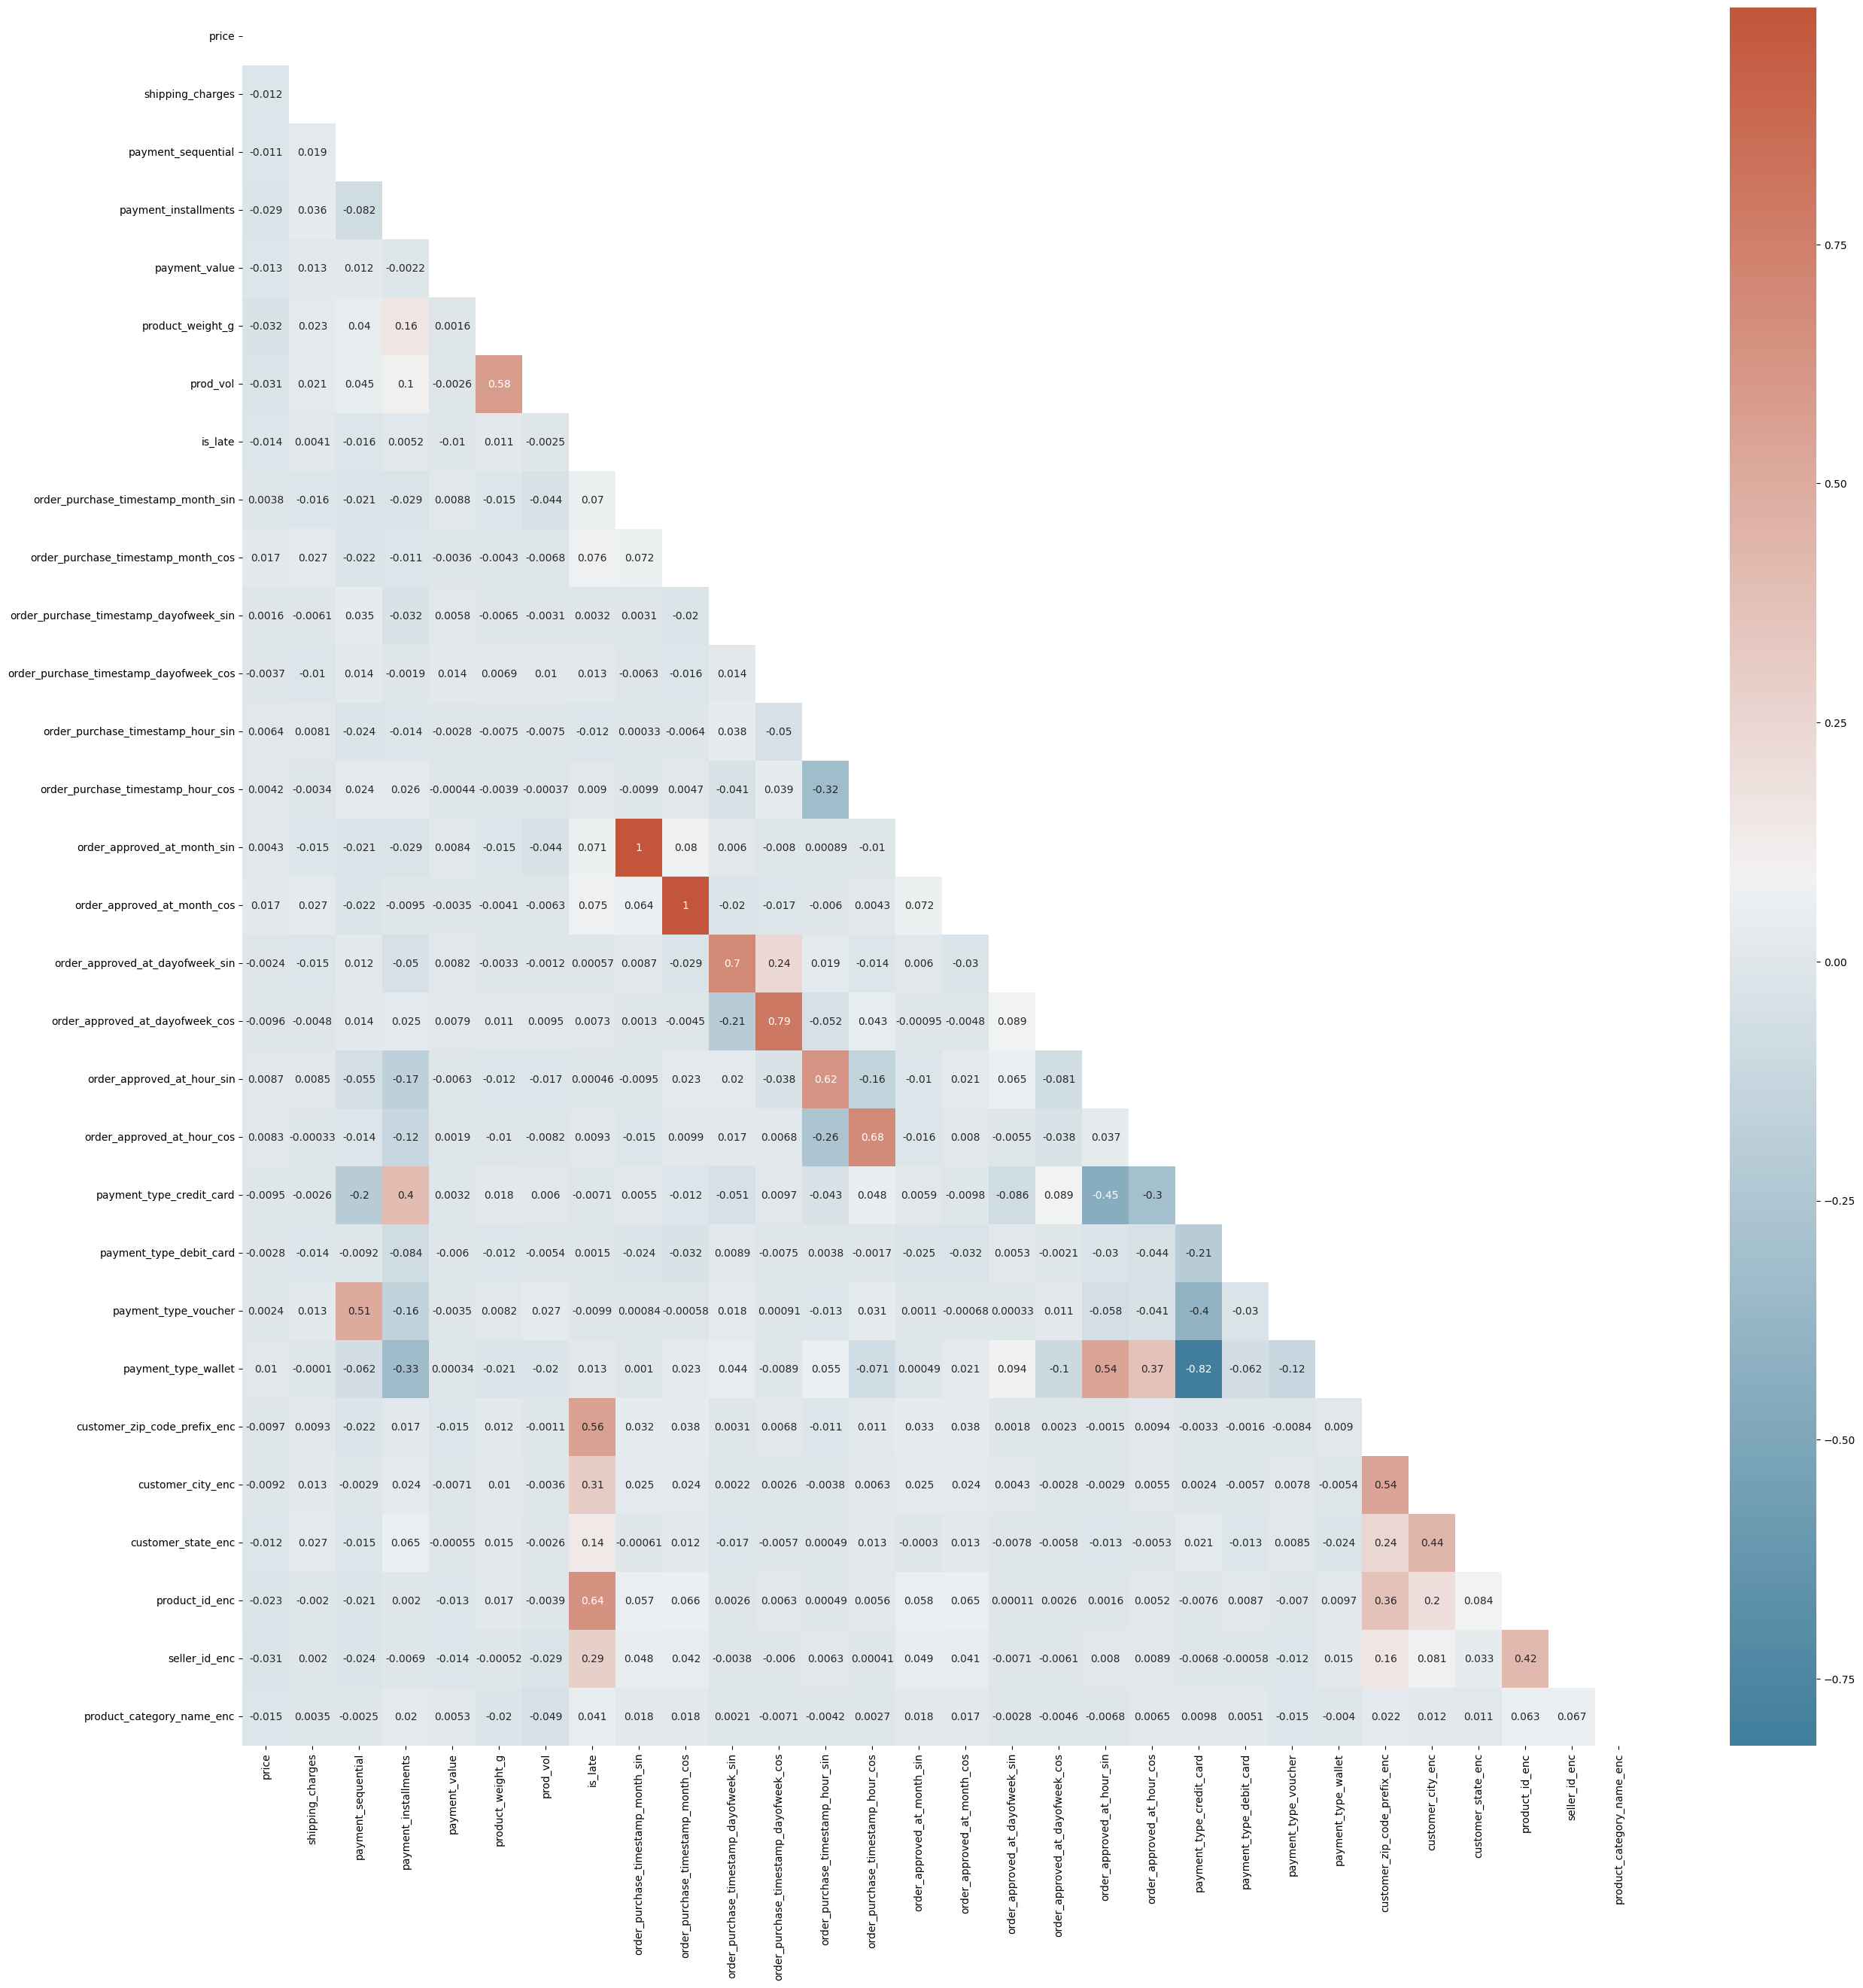

In [40]:
f, dx = plt.subplots(figsize=(30,30))
cmap = sns.diverging_palette(230, 20, as_cmap=True)
sns.heatmap(corr, mask=mask, cmap=cmap, annot=True)

In [41]:
bottom = corr.abs().where(~mask)
bottom

,price,shipping_charges,payment_sequential,payment_installments,payment_value,product_weight_g,prod_vol,is_late,order_purchase_timestamp_month_sin,order_purchase_timestamp_month_cos,order_purchase_timestamp_dayofweek_sin,order_purchase_timestamp_dayofweek_cos,order_purchase_timestamp_hour_sin,order_purchase_timestamp_hour_cos,order_approved_at_month_sin,order_approved_at_month_cos,order_approved_at_dayofweek_sin,order_approved_at_dayofweek_cos,order_approved_at_hour_sin,order_approved_at_hour_cos,payment_type_credit_card,payment_type_debit_card,payment_type_voucher,payment_type_wallet,customer_zip_code_prefix_enc,customer_city_enc,customer_state_enc,product_id_enc,seller_id_enc,product_category_name_enc
price,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
shipping_charges,0.011863,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
payment_sequential,0.011198,0.019349,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
payment_installments,0.029368,0.036434,0.082105,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
payment_value,0.013251,0.012500,0.011787,0.002161,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
product_weight_g,0.032413,0.023319,0.040339,0.155863,0.001568,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
prod_vol,0.031005,0.020684,0.044863,0.099589,0.002619,0.584869,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
is_late,0.013718,0.004085,0.016064,0.005183,0.010304,0.011100,0.002490,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
order_purchase_timestamp_month_sin,0.003793,0.015564,0.020836,0.029171,0.008843,0.014865,0.043637,0.069586,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
order_purchase_timestamp_month_cos,0.016931,0.027451,0.022418,0.010610,0.003596,0.004328,0.006841,0.075715,0.071528,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN


In [47]:
to_drop = [column for column in bottom.columns if any(bottom[column] >= 0.9)]
df = df.drop(columns=to_drop)

<Axes: >

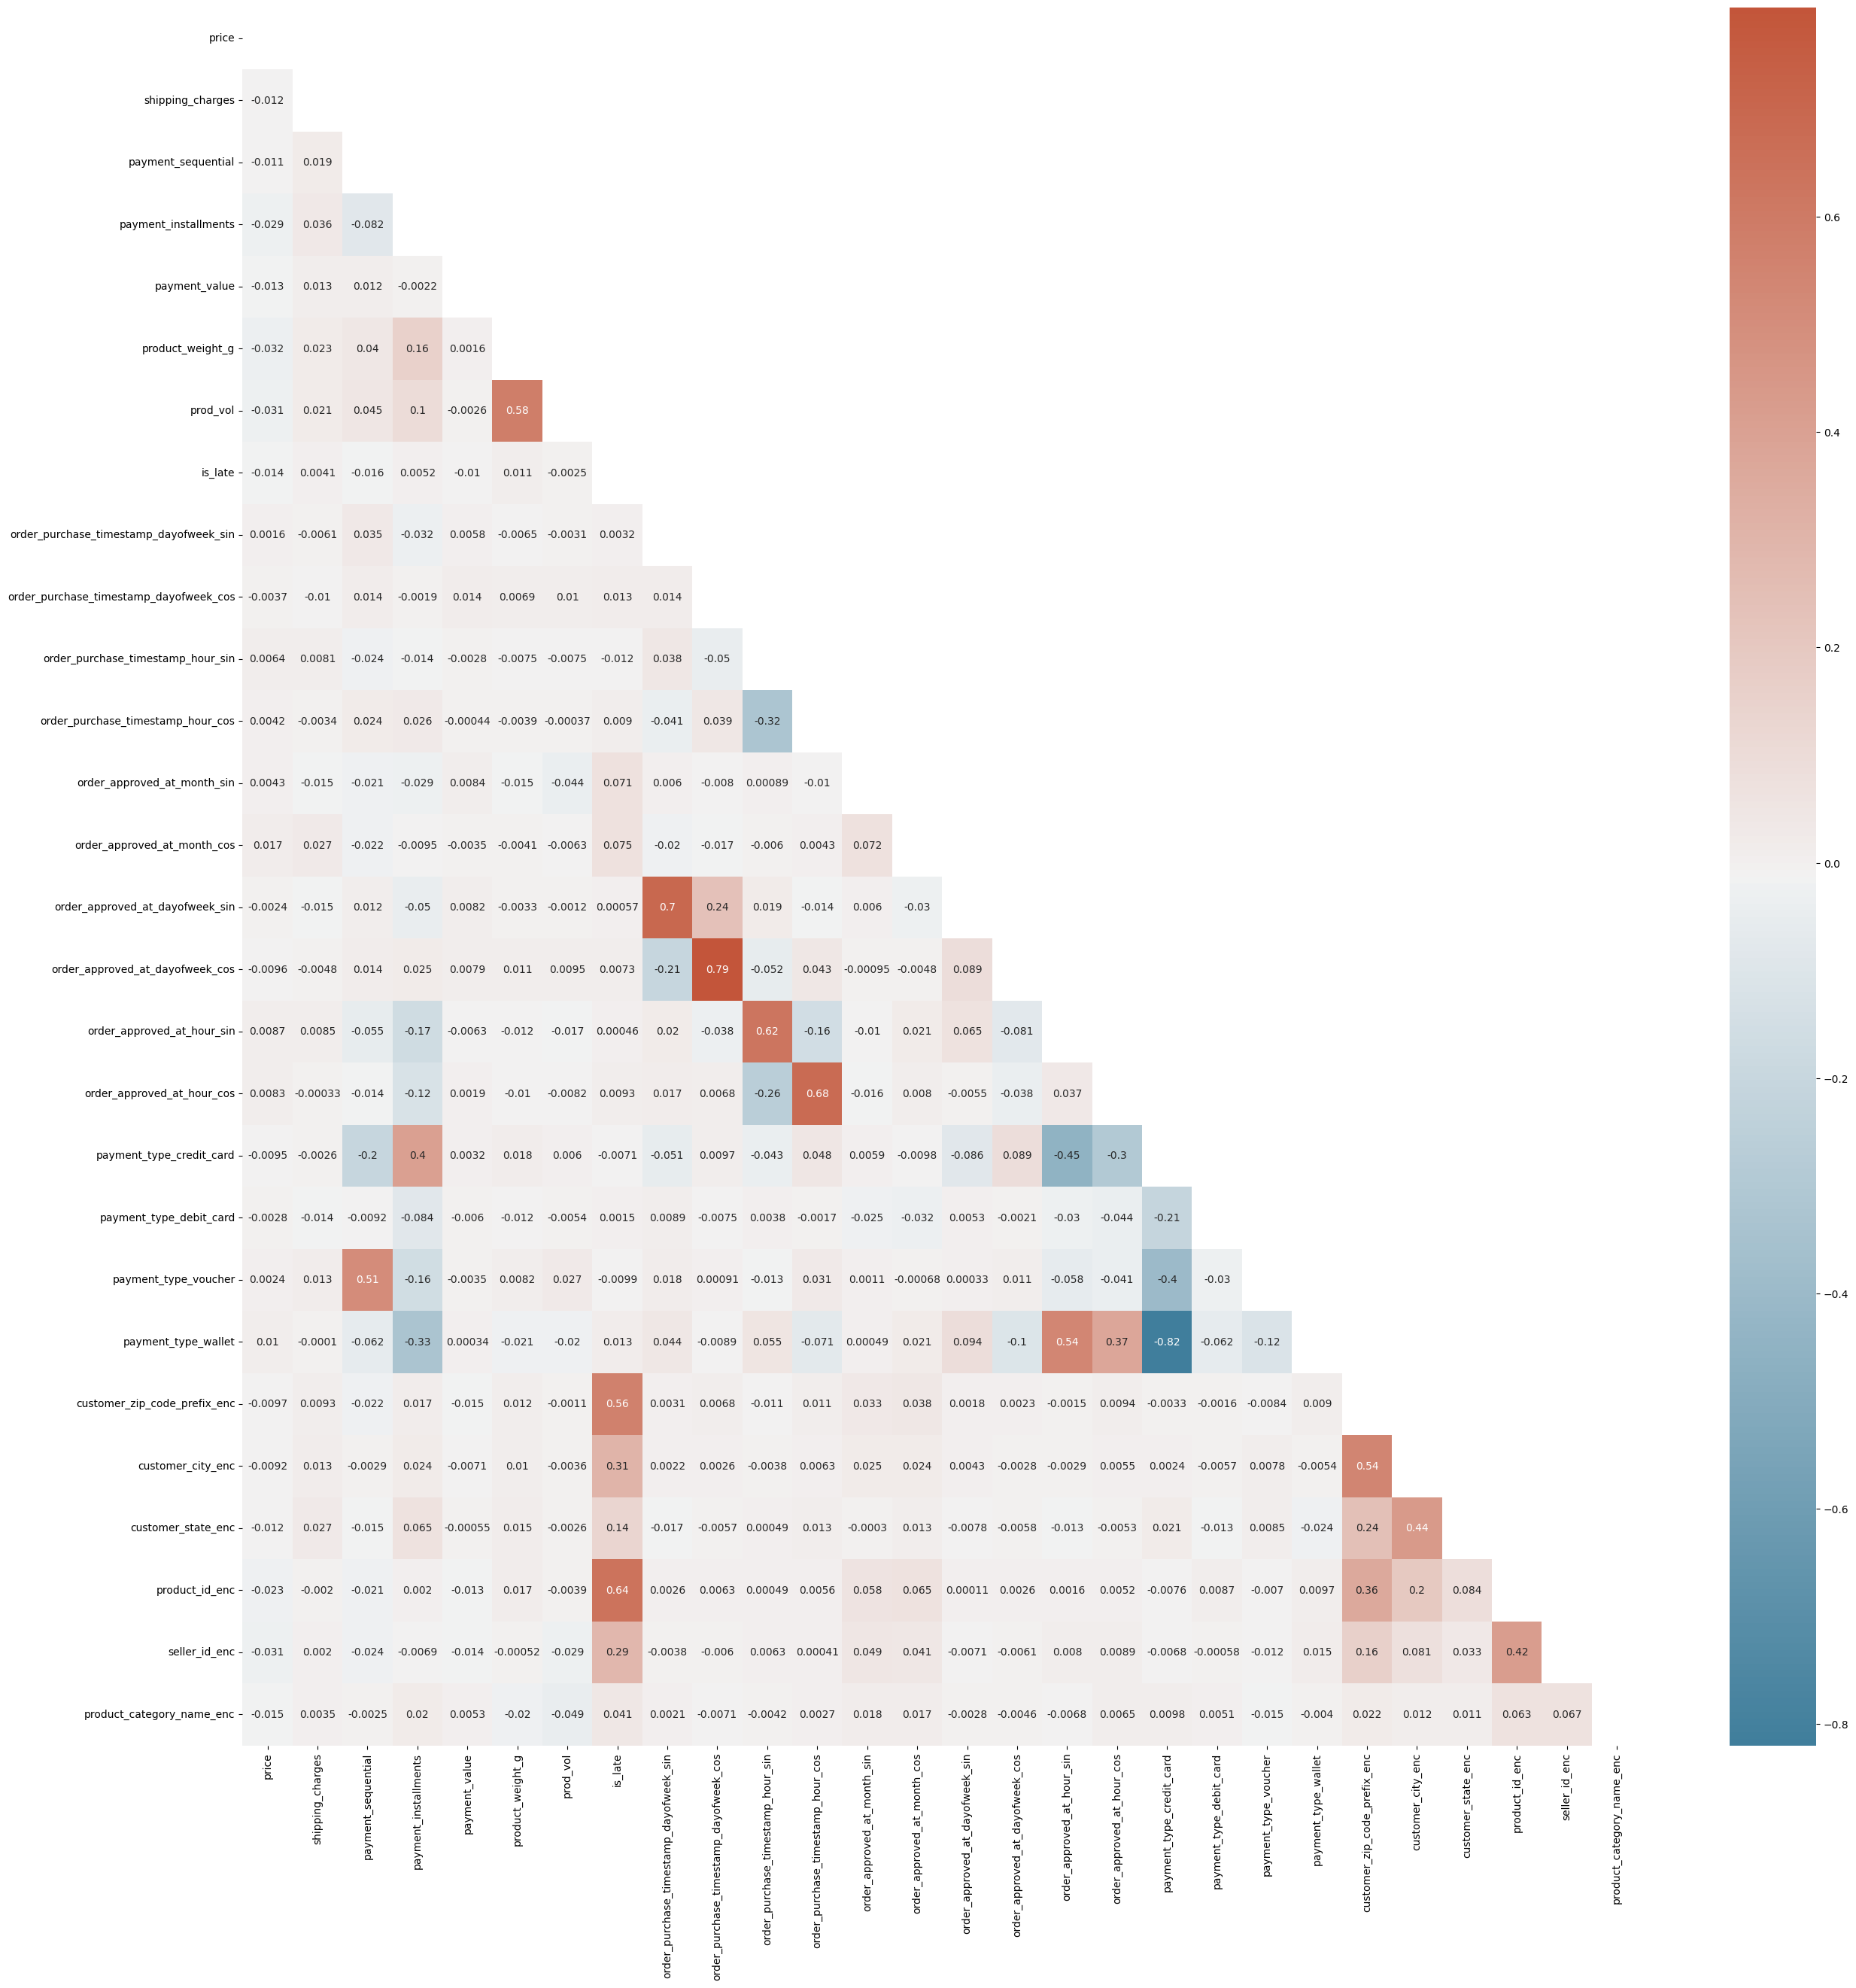

In [48]:
corr = df.corr()
mask = np.triu(np.ones_like(corr, dtype=bool))
f, dx = plt.subplots(figsize=(30,30))
cmap = sns.diverging_palette(230, 20, as_cmap=True)
sns.heatmap(corr, mask=mask, cmap=cmap, annot=True)

## Разбиение на train-test
Чаще всего разбивают в отношении 80%-20%

In [50]:
X = df.drop('is_late', axis=1)
y = df['is_late']
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

df_train = X_train.join(y_train)
df_train

,price,shipping_charges,payment_sequential,payment_installments,payment_value,product_weight_g,prod_vol,order_purchase_timestamp_dayofweek_sin,order_purchase_timestamp_dayofweek_cos,order_purchase_timestamp_hour_sin,order_purchase_timestamp_hour_cos,order_approved_at_month_sin,order_approved_at_month_cos,order_approved_at_dayofweek_sin,order_approved_at_dayofweek_cos,order_approved_at_hour_sin,order_approved_at_hour_cos,payment_type_credit_card,payment_type_debit_card,payment_type_voucher,payment_type_wallet,customer_zip_code_prefix_enc,customer_city_enc,customer_state_enc,product_id_enc,seller_id_enc,product_category_name_enc,is_late
80426,0.053540,0.691823,2,1,0.152071,0.030864,0.028689,0.781831,0.623490,-0.500000,-8.660254e-01,8.660254e-01,5.000000e-01,0.974928,-0.222521,-0.500000,-8.660254e-01,0,0,1,0,0.000000,0.102544,0.122304,0.000000,0.080851,0.000000,0
30269,0.129802,0.224274,2,1,0.274924,0.098765,0.072104,0.000000,1.000000,-0.965926,2.588190e-01,5.000000e-01,-8.660254e-01,0.000000,1.000000,-0.866025,5.000000e-01,0,0,1,0,0.000000,0.073831,0.072993,0.074074,0.054605,0.074600,0
23718,0.157139,0.325579,1,6,0.256456,0.580247,0.509385,0.781831,0.623490,-0.707107,7.071068e-01,8.660254e-01,-5.000000e-01,0.781831,0.623490,-0.707107,7.071068e-01,1,0,0,0,0.000000,0.048780,0.039216,0.000000,0.055556,0.075408,0
15089,0.062326,0.258723,1,1,0.932597,0.543210,0.062872,-0.433884,-0.900969,-0.965926,2.588190e-01,1.000000e+00,6.123234e-17,-0.433884,-0.900969,-0.866025,5.000000e-01,1,0,0,0,0.000000,0.059273,0.055478,0.117647,0.030864,0.075408,0
53196,0.036212,0.277368,1,1,0.054324,0.370370,0.203266,0.433884,-0.900969,-0.500000,8.660254e-01,8.660254e-01,-5.000000e-01,-0.974928,-0.222521,0.500000,8.660254e-01,0,0,0,1,0.250000,0.207792,0.155303,0.111111,0.056604,0.075408,1
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
85039,0.943846,0.630560,1,1,0.141611,0.333333,0.155883,0.781831,0.623490,-0.965926,2.588190e-01,-5.000000e-01,-8.660254e-01,0.433884,-0.900969,0.707107,7.071068e-01,0,0,0,1,0.000000,0.016667,0.051817,0.103448,0.156627,0.075408,0
59818,0.294782,0.054604,1,1,0.266900,0.190123,0.324279,0.433884,-0.900969,-0.707107,7.071068e-01,8.660254e-01,-5.000000e-01,0.433884,-0.900969,-0.707107,7.071068e-01,1,0,0,0,0.000000,0.000000,0.055478,0.000000,0.074627,0.085271,0
1364,0.138588,0.334547,1,2,0.347990,0.185185,0.918358,0.433884,-0.900969,1.000000,6.123234e-17,-8.660254e-01,-5.000000e-01,0.433884,-0.900969,1.000000,6.123234e-17,1,0,0,0,0.055556,0.040984,0.051817,0.000000,0.096774,0.075408,0
24828,0.104745,0.126520,1,1,0.077162,0.037037,0.029300,0.974928,-0.222521,0.000000,1.000000e+00,-2.449294e-16,1.000000e+00,0.433884,-0.900969,0.707107,7.071068e-01,0,0,0,1,0.000000,0.000000,0.055478,0.000000,0.035714,0.075408,0


In [52]:
class_counts = df['is_late'].value_counts()
print(f'Всего количество значений в каждом классе {class_counts}')

class_percentage = df_train['is_late'].value_counts(normalize=True)*100
print(f'Всего количество значений в процентном соотношении {class_percentage}')

Всего количество значений в каждом классе is_late
0    52774
1     4275
Name: count, dtype: int64
Всего количество значений в процентном соотношении is_late
0    92.521747
1     7.478253
Name: proportion, dtype: float64


# 8. Техники семплирования
**Мажорный класс** - тот, в котором больше экземпляров (семплов)

**Минорный класс** - тот, в котором меньше экземпляров (семплов)

1) **Undersampling**. Минорный класс оставляется какой есть, а из мажорного берём столько, сколько было минорных.
2) **Oversampling**. Мажорный класс оставляем как есть, а в минорном добавляем "на те же места". То есть количество экземпляров равно, но у минорного будут дубли.
3) **SMOTE (Synthetic Minority Over-sampling Technique)**. Синтетически генерируем минорные семплы. Берутся два рандомных минорных семпла и на их линии рандомно генерируется новый. И так до тех пор, пока количество минорных и мажорных не сравняется.

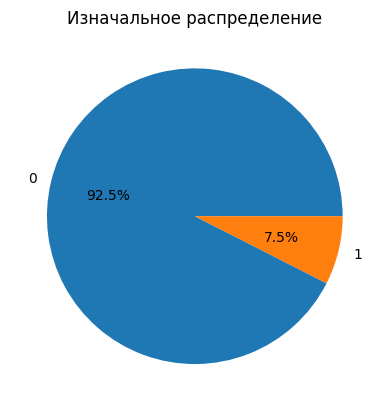

In [54]:
class_counts.plot(kind='pie', title='Изначальное распределение', autopct='%1.1f%%')
plt.show()

In [55]:
# Распределим
majority_class = df_train[df_train['is_late'] == 0]
minority_class = df_train[df_train['is_late'] == 1]

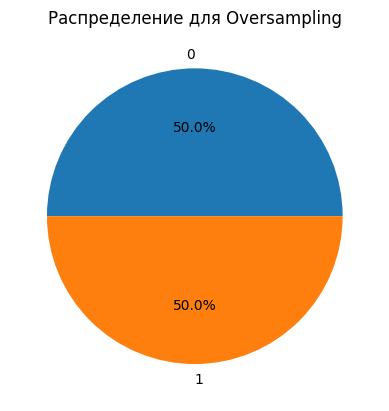

Всего элементов после Oversampling: 84452


In [56]:
# 1) Oversampling
minority_oversampled = resample(minority_class, n_samples=len(majority_class), random_state=42)
df_oversampled = pd.concat([majority_class, minority_oversampled])
df_oversampled['is_late'].value_counts().plot(kind='pie', title='Распределение для Oversampling', autopct='%1.1f%%')
plt.show()
print(f'Всего элементов после Oversampling: {len(df_oversampled)}')

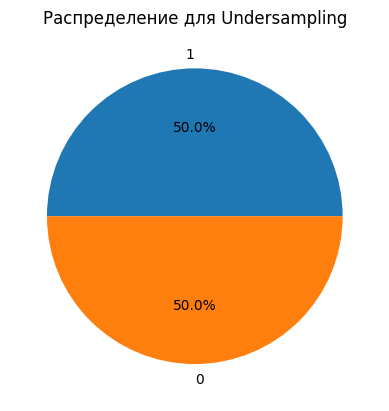

Всего элементов после Undersampling: 6826


In [57]:
# 1) Undersampling
majority_undersampled = resample(majority_class, n_samples=len(minority_class), random_state=42)
df_undersampled = pd.concat([minority_class, majority_undersampled])
df_undersampled['is_late'].value_counts().plot(kind='pie', title='Распределение для Undersampling', autopct='%1.1f%%')
plt.show()
print(f'Всего элементов после Undersampling: {len(df_undersampled)}')

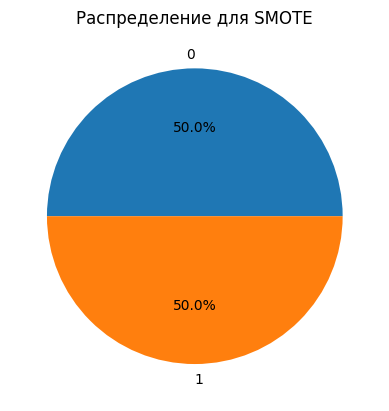

Всего элементов после SMOTE: 84452


In [58]:
smote = SMOTE(random_state=42)
X_smote, y_smote = smote.fit_resample(X_train, y_train)

df_smote = pd.concat([X_smote, y_smote], axis=1)
df_smote['is_late'].value_counts().plot(kind='pie', title='Распределение для SMOTE', autopct='%1.1f%%')
plt.show()
print(f'Всего элементов после SMOTE: {len(df_smote)}')


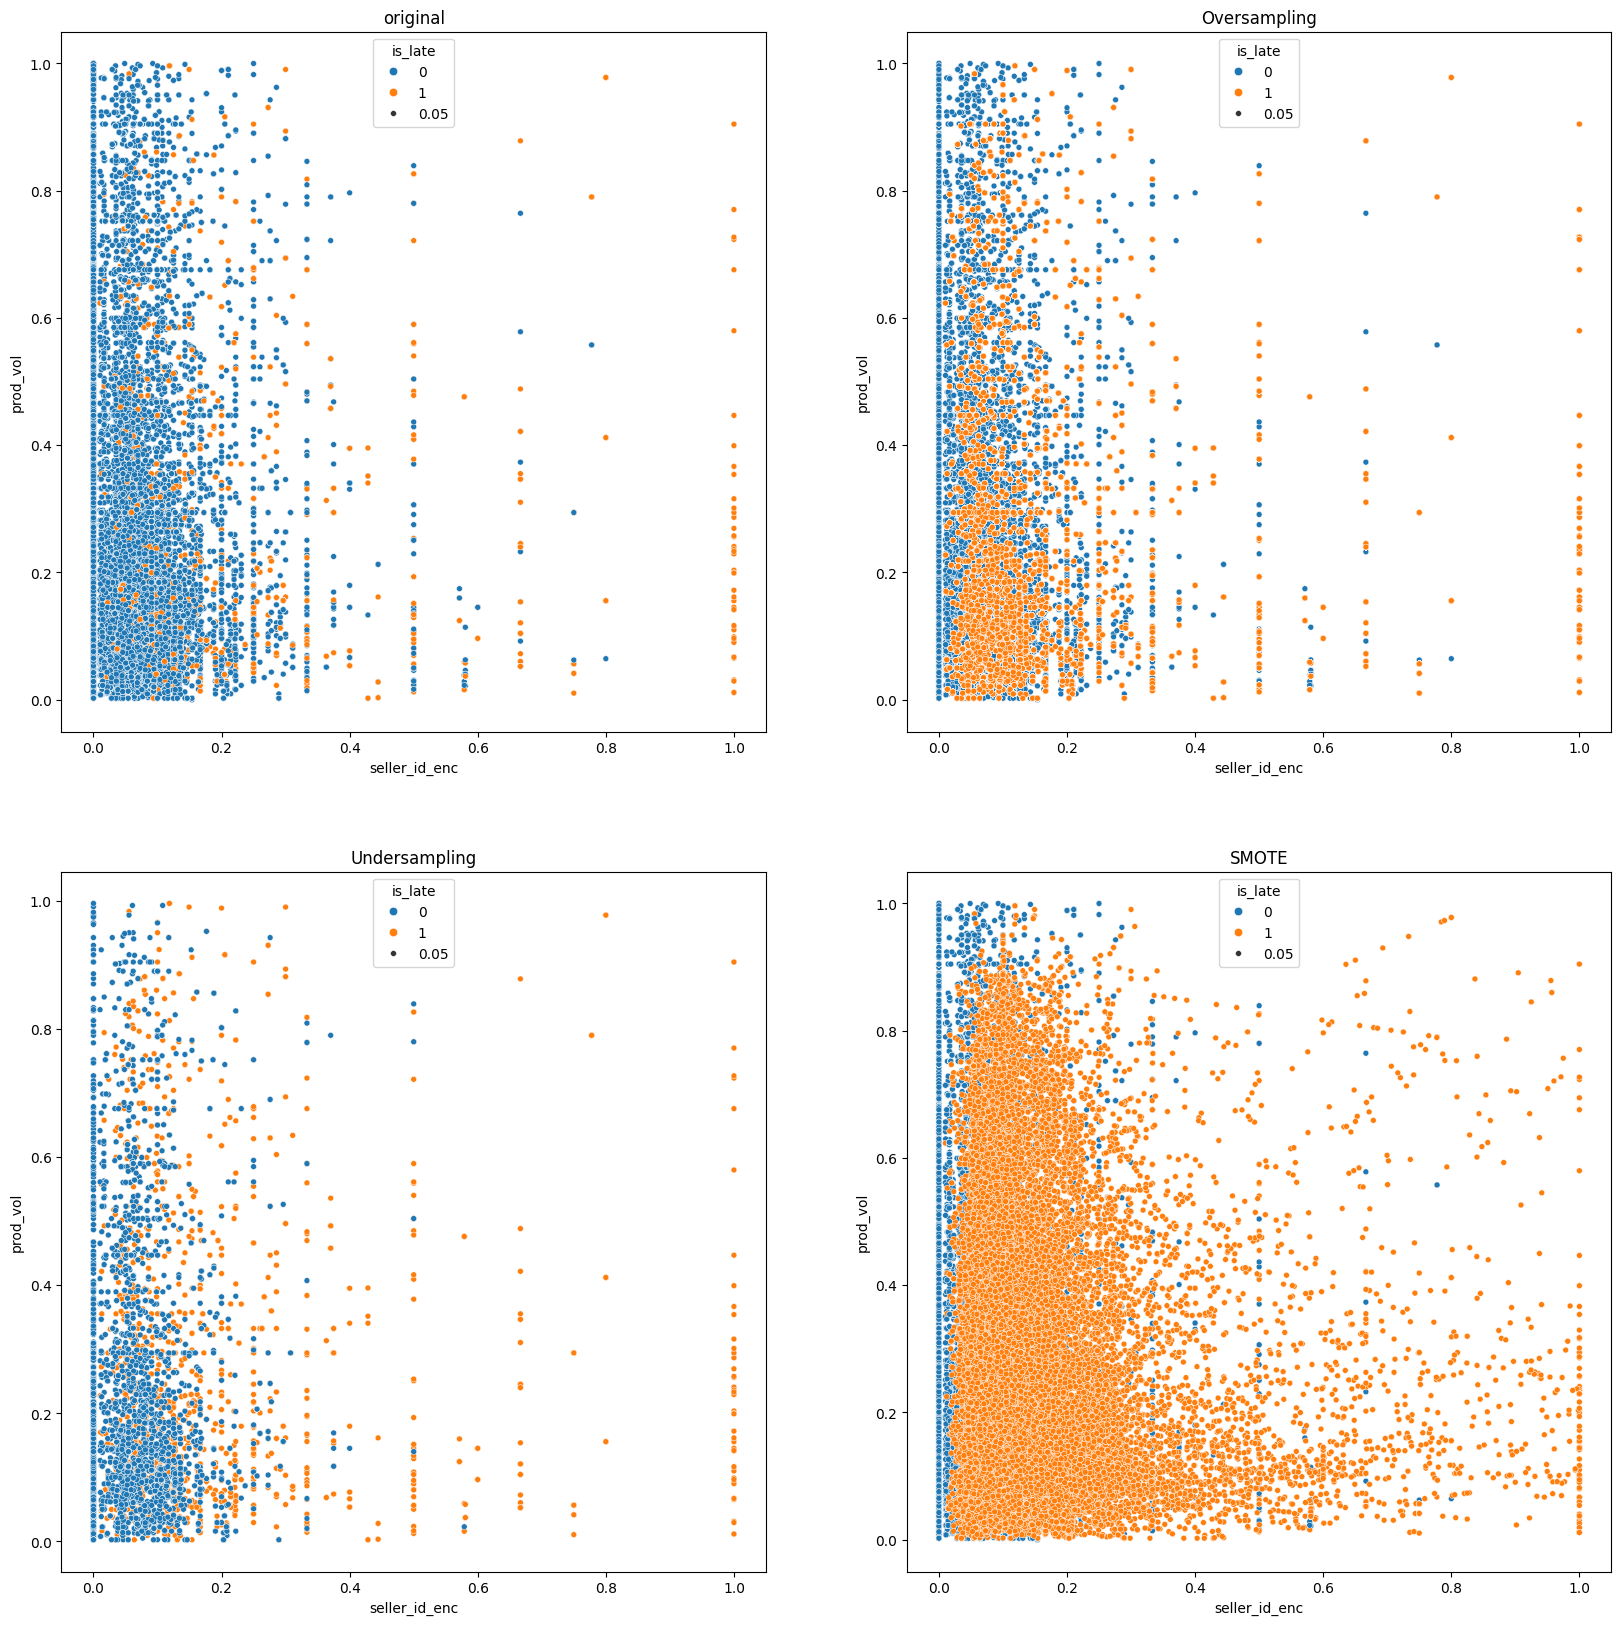

In [60]:
feature_1 = 'seller_id_enc'
feature_2 = 'prod_vol'

fig, ax = plt.subplots(2,2, figsize=(20,20))

sns.scatterplot(x=feature_1, y=feature_2, hue='is_late', data=df_train, ax=ax[0][0], size=0.05)
ax[0][0].set_title('original')

sns.scatterplot(x=feature_1, y=feature_2, hue='is_late', data=df_oversampled, ax=ax[0][1], size=0.05)
ax[0][1].set_title('Oversampling')

sns.scatterplot(x=feature_1, y=feature_2, hue='is_late', data=df_undersampled, ax=ax[1][0], size=0.05)
ax[1][0].set_title('Undersampling')

sns.scatterplot(x=feature_1, y=feature_2, hue='is_late', data=df_smote, ax=ax[1][1], size=0.05)
ax[1][1].set_title('SMOTE')

plt.show()